In [25]:
import matplotlib as mpl
import seaborn as sns
import importlib

# Seaborn theme
sns.set_theme(
    style="ticks",        # "white", "whitegrid", "ticks", "darkgrid"
    context="paper",       # notebook, paper, talk, poster
    palette="deep"
)

# Your publication formatting
mpl.rcParams.update({

    # Fonts
    "font.family": "Arial",
    "font.size": 14,

    # Figure titles
    "figure.titlesize": 34,
    "figure.titleweight": "bold",

    # Axes titles/labels
    "axes.titlesize": 14,
    "axes.labelsize": 14,

    # Tick labels
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,

    # Legend
    "legend.fontsize": 10,
    "legend.title_fontsize": 12,

    # Lines & markers
    "lines.linewidth": 3,
    "lines.markersize": 8,

    # Axes
    "axes.linewidth": 2,

    # Ticks
    "xtick.major.size": 8,
    "ytick.major.size": 8,
    "xtick.major.width": 2,
    "ytick.major.width": 2,
    "xtick.minor.size": 4,
    "ytick.minor.size": 4,
    "xtick.minor.width": 1.5,
    "ytick.minor.width": 1.5,

    # Grid
    "grid.linewidth": 1,
    "grid.alpha": 0.3,

    # Export
    "figure.dpi": 150,
    "savefig.dpi": 600,

    # Editable vector graphics
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})

# Manuscript Figure 4 — Local curvature predicts heterogeneous retention and occupancy

Builds receptor-resolved maps and tests local curvature while accounting for surface height and local receptor spacing.


In [26]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "analysis_tools":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from analysis_tools.manuscript_escape_analysis import (
    classical_occupancy, condition_statistics, discover_runs,
    load_receptor_summaries, occupancy_from_bound_time,
    replicate_survival_curves, save_figure, summarize_replicates,
)

SAVE_FIGURES = False
FIGURE_ROOT = PROJECT_ROOT / "analysis_tools" / "manuscript_panels"

import importlib
from scipy.spatial import cKDTree
import utils.escape_assay_viz as escape_assay_viz
importlib.reload(escape_assay_viz)
from utils.escape_assay_viz import load_escape_assay_run, plot_surface_metric_3d, plot_surface_metric_xy


In [21]:
DATA_ROOT = "/Users/rynon/Library/CloudStorage/OneDrive-NorthwesternUniversity/PhD/Data/Agent-based simulations/261005_manuscript_fig4_sinusoidal_local_curvature"
run_index = discover_runs(DATA_ROOT)
replicates = summarize_replicates(run_index)
receptors = load_receptor_summaries(run_index)
print(f"{len(run_index)} replicates, {len(receptors):,} receptor locations")
display(replicates[["replicate","n_receptors","n_trajectories","censoring_fraction","mean_bound_time_s","mean_rebindings"]])


20 replicates, 25,140 receptor locations


,replicate,n_receptors,n_trajectories,censoring_fraction,mean_bound_time_s,mean_rebindings
0,1,1257,125700,0.000127,1044.624664,9.447908
1,2,1257,125700,0.000143,1044.175709,9.439825
2,3,1257,125700,0.000072,1041.614062,9.421042
3,4,1257,125700,0.000103,1052.985679,9.531504
4,5,1257,125700,0.000080,1070.965166,9.700589
5,6,1257,125700,0.000088,1060.121463,9.606420
6,7,1257,125700,0.000119,1064.979627,9.640621
7,8,1257,125700,0.000064,1045.945316,9.465617
8,9,1257,125700,0.000064,1042.381860,9.433882
9,10,1257,125700,0.000095,1042.237231,9.412029


## 1. Add local receptor-neighborhood covariates


In [22]:
enriched=[]
for run_dir, frame in receptors.groupby("run_directory", sort=False):
    frame=frame.copy()
    xyz=frame[["surface_x_m","surface_y_m","surface_z_m"]].to_numpy(float)
    tree=cKDTree(xyz)
    distances,_=tree.query(xyz,k=min(2,len(xyz)))
    frame["nearest_receptor_distance_m"] = distances[:,-1] if len(xyz)>1 else np.nan
    frame["neighbors_within_10nm"] = np.array([len(v)-1 for v in tree.query_ball_point(xyz,10e-9)])
    enriched.append(frame)
receptors=pd.concat(enriched,ignore_index=True)
curvature_column="mean_curvature_m_inv"
receptors["mean_curvature_nm_inv"]=receptors[curvature_column]*1e-9


## 2. Figure 4A–C: representative spatial maps


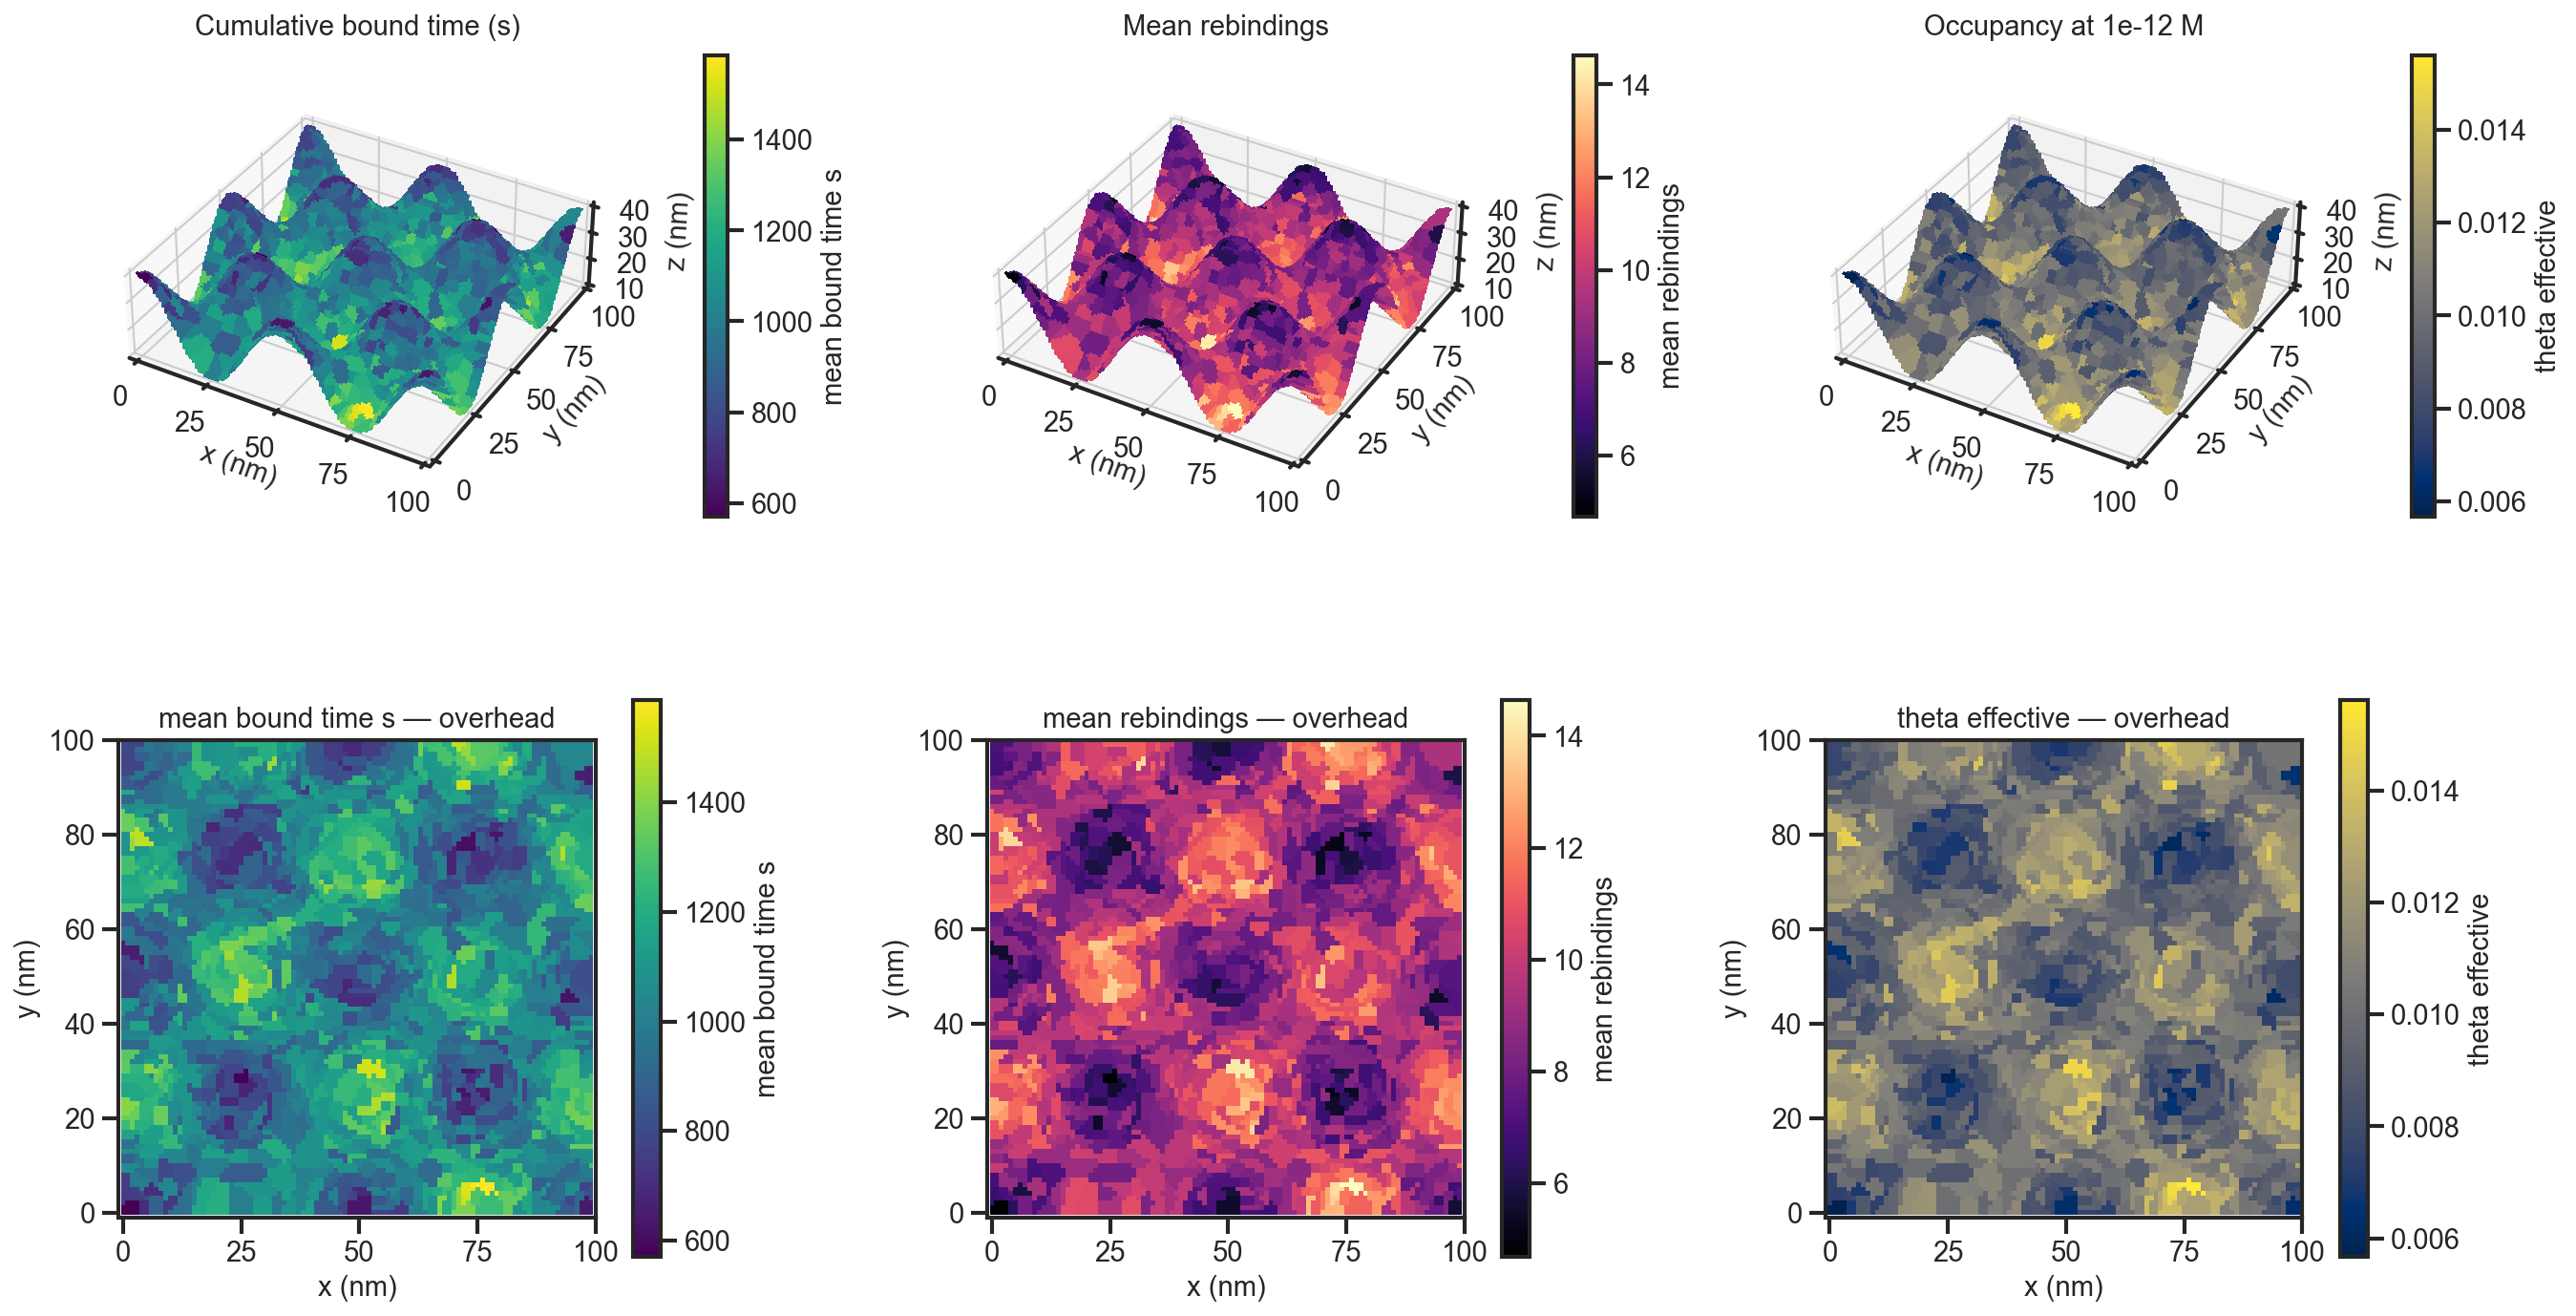

In [27]:
SELECTED_REPLICATE = int(run_index.replicate.min())
MAP_CONCENTRATION_M = 1e-12
selected_row=run_index.loc[run_index.replicate.eq(SELECTED_REPLICATE)].iloc[0]
archive=load_escape_assay_run(selected_row.run_directory)
map_summary=archive.receptor_summary.copy()
map_summary["theta_effective"] = occupancy_from_bound_time(map_summary.mean_bound_time_s, archive.params.k_on_M_inv_s, MAP_CONCENTRATION_M)
panels=[("mean_bound_time_s","viridis","Cumulative bound time (s)"),("mean_rebindings","magma","Mean rebindings"),("theta_effective","cividis",rf"Occupancy at {MAP_CONCENTRATION_M:.0e} M")]
fig=plt.figure(figsize=(18,10),constrained_layout=True)
for j,(metric,cmap,title) in enumerate(panels):
    ax=fig.add_subplot(2,3,j+1,projection="3d")
    plot_surface_metric_3d(archive.geometry,map_summary,metric,a_m=archive.params.a_m,cmap=cmap,show_receptors=False,colorbar_pad=0.18,ax=ax)
    ax.view_init(elev=35,azim=-60); ax.set_title(title)
    ax2=fig.add_subplot(2,3,j+4)
    plot_surface_metric_xy(archive.geometry,map_summary,metric,a_m=archive.params.a_m,cmap=cmap,show_receptors=False,ax=ax2)
if SAVE_FIGURES: save_figure(fig,FIGURE_ROOT,"figure4_ABC_spatial_maps")
plt.show()


## 3. Figure 4D–E: curvature relationships


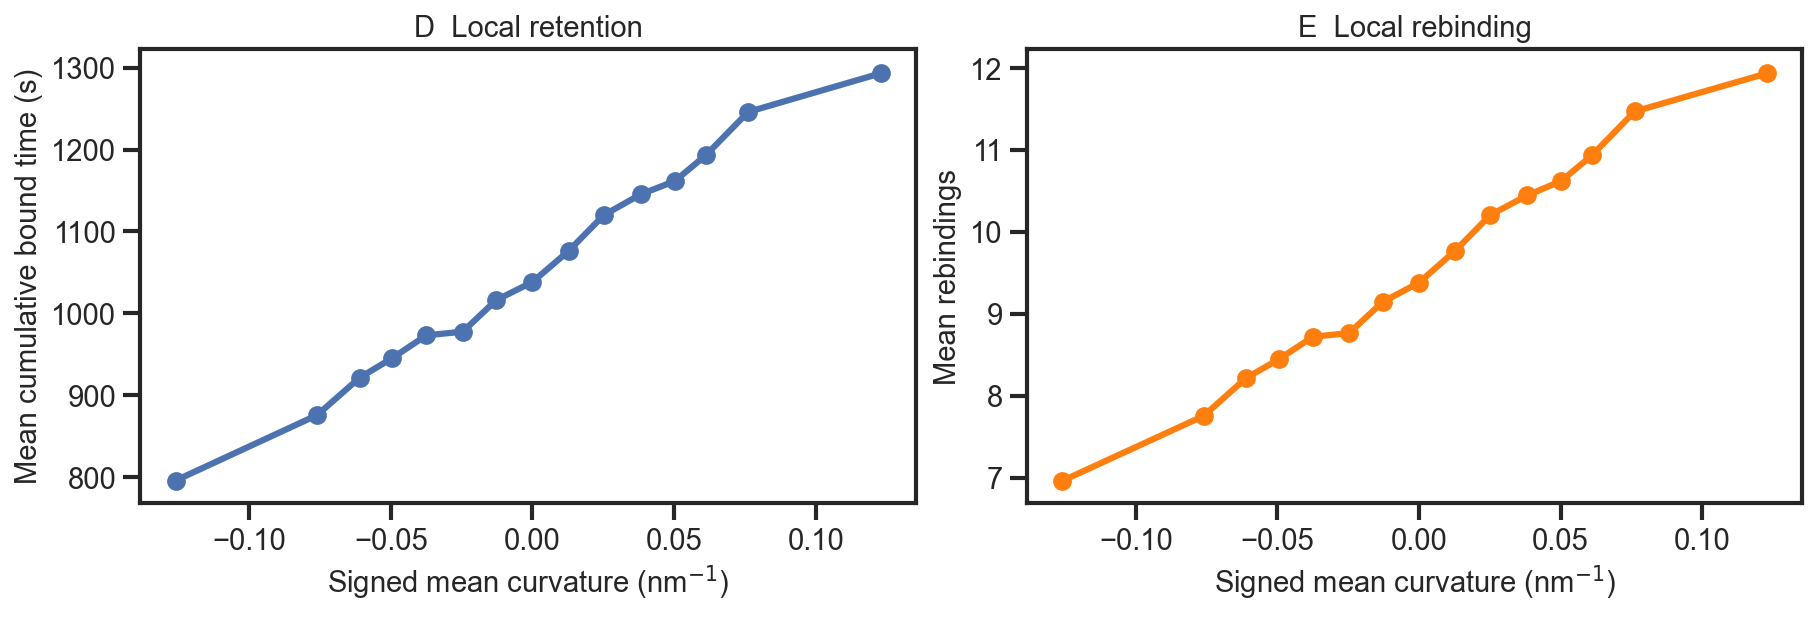

In [28]:
receptors["curvature_bin"] = pd.qcut(receptors.mean_curvature_nm_inv, 15, duplicates="drop")
per_rep_bin=(receptors.groupby(["replicate","curvature_bin"],observed=True).agg(curvature=("mean_curvature_nm_inv","mean"),bound_time=("mean_bound_time_s","mean"),rebindings=("mean_rebindings","mean")).reset_index())
binned=(per_rep_bin.groupby("curvature_bin",observed=True).agg(curvature=("curvature","mean"),bound_mean=("bound_time","mean"),bound_sem=("bound_time","sem"),rebind_mean=("rebindings","mean"),rebind_sem=("rebindings","sem")).reset_index())
fig,axes=plt.subplots(1,2,figsize=(12,4),constrained_layout=True)
axes[0].errorbar(binned.curvature,binned.bound_mean,yerr=binned.bound_sem,marker="o",capsize=2)
axes[1].errorbar(binned.curvature,binned.rebind_mean,yerr=binned.rebind_sem,marker="o",capsize=2,color="tab:orange")
axes[0].set(xlabel=r"Signed mean curvature (nm$^{-1}$)",ylabel="Mean cumulative bound time (s)",title="D  Local retention")
axes[1].set(xlabel=r"Signed mean curvature (nm$^{-1}$)",ylabel="Mean rebindings",title="E  Local rebinding")
if SAVE_FIGURES: save_figure(fig,FIGURE_ROOT,"figure4_DE_curvature_relationships")
plt.show()


## 4. Multivariable receptor-level model

Replicate indicator terms account for layout-to-layout shifts. Predictors are standardized before fitting.


In [ ]:
predictors=["mean_curvature_m_inv","gaussian_curvature_m_inv2","surface_z_m","nearest_receptor_distance_m","neighbors_within_10nm"]
data=receptors.dropna(subset=predictors+["mean_bound_time_s"]).copy()
Xparts=[np.ones(len(data))]; names=["intercept"]
for name in predictors:
    values=data[name].to_numpy(float); values=(values-values.mean())/values.std()
    Xparts.append(values); names.append(name)
replicate_dummies=pd.get_dummies(data.replicate,drop_first=True,dtype=float)
Xparts.extend([replicate_dummies[col].to_numpy() for col in replicate_dummies]); names.extend([f"replicate_{col}" for col in replicate_dummies])
X=np.column_stack(Xparts); y=np.log(np.clip(data.mean_bound_time_s.to_numpy(float),1e-12,None))
beta,*_=np.linalg.lstsq(X,y,rcond=None); residual=y-X@beta
cov=np.linalg.pinv(X.T@X)*(residual@residual)/(len(y)-X.shape[1])
coefficients=pd.DataFrame({"term":names,"coefficient":beta,"standard_error":np.sqrt(np.diag(cov))})
coefficients["t_value"]=coefficients.coefficient/coefficients.standard_error
display(coefficients.iloc[:len(predictors)+1])


,term,coefficient,standard_error,t_value
0,intercept,6.939346,0.002976,2331.539749
1,mean_curvature_m_inv,-0.001142,0.002380,-0.479715
2,gaussian_curvature_m_inv2,-0.002173,0.000700,-3.103137
3,surface_z_m,-0.137568,0.002379,-57.826910
4,nearest_receptor_distance_m,-0.012588,0.000680,-18.502659
5,neighbors_within_10nm,0.014378,0.000714,20.135016


In [ ]:
if SAVE_FIGURES:
    out=FIGURE_ROOT/"figure4_tables"; out.mkdir(parents=True,exist_ok=True)
    binned.to_csv(out/"figure4_curvature_bins.csv",index=False)
    coefficients.to_csv(out/"figure4_multivariable_model.csv",index=False)
